In [7]:
# Llama-3.2 is gated. Store a Kaggle secret named HF_TOKEN.
from kaggle_secrets import UserSecretsClient
from huggingface_hub import login

try:
    token = UserSecretsClient().get_secret('HF_TOKEN')
    login(token=token)
    print('Hugging Face login: OK')
except Exception as exc:
    print('HF login was not completed automatically:', exc)
    print('If the model is already cached and accessible, you can continue.')


Hugging Face login: OK


In [8]:
import torch
from transformers import AutoModelForCausalLM
import matplotlib.pyplot as plt

model = AutoModelForCausalLM.from_pretrained('meta-llama/Llama-3.2-1B',)

config.json:   0%|          | 0.00/843 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 2.47GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/185 [00:00<?, ?B/s]

In [9]:
from pathlib import Path
import pandas as pd

#OUTPUT_DIR = Path('/kaggle/working/Assignment1/Q4')
OUTPUT_DIR = Path('.')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

LAYERS = [0, 7, 15]
SVD_DEVICE = torch.device(
    'cuda:0' if torch.cuda.is_available() else 'cpu'
)

spectra = {}
summary_rows = []

with torch.no_grad():
    for layer_id in LAYERS:
        W = (
            model.model.layers[layer_id]
            .self_attn.q_proj.weight
            .detach()
            .to(device=SVD_DEVICE, dtype=torch.float32)
        )

        # 完整 SVD；不做 rank 截斷
        U, S, Vh = torch.linalg.svd(
            W, full_matrices=False
        )
        S = S.cpu()

        energy = S.double().square()
        total_energy = energy.sum()

        if not torch.isfinite(total_energy) or total_energy <= 0:
            raise ValueError(f'Invalid energy in layer {layer_id}')

        cumulative = energy.cumsum(dim=0) / total_energy
        r50 = int(
            torch.nonzero(cumulative >= 0.5)[0, 0].item()
        ) + 1

        spectra[layer_id] = {
            'singular_values': S.numpy(),
            'cumulative_energy_pct': (cumulative * 100).numpy(),
            'rank_50': r50,
        }

        summary_rows.append({
            'layer': layer_id,
            'weight_shape': str(tuple(W.shape)),
            'minimum_rank_50pct': r50,
            'energy_at_rank_pct': cumulative[r50 - 1].item() * 100,
            'energy_before_rank_pct': (
                cumulative[r50 - 2].item() * 100
                if r50 > 1 else 0.0
            ),
        })

        # 儲存全部奇異值，方便核對與重畫
        pd.DataFrame({
            'rank': range(1, len(S) + 1),
            'singular_value': S.numpy(),
            'cumulative_energy_pct': (
                cumulative * 100
            ).numpy(),
        }).to_csv(
            OUTPUT_DIR / f'layer_{layer_id}_spectrum.csv',
            index=False,
        )

        del W, U, S, Vh
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(OUTPUT_DIR / 'q4_summary.csv', index=False)
display(summary_df)

,layer,weight_shape,minimum_rank_50pct,energy_at_rank_pct,energy_before_rank_pct
0,0,"(2048, 2048)",62,50.166257,49.929382
1,7,"(2048, 2048)",120,50.195703,49.987324
2,15,"(2048, 2048)",84,50.111583,49.867152


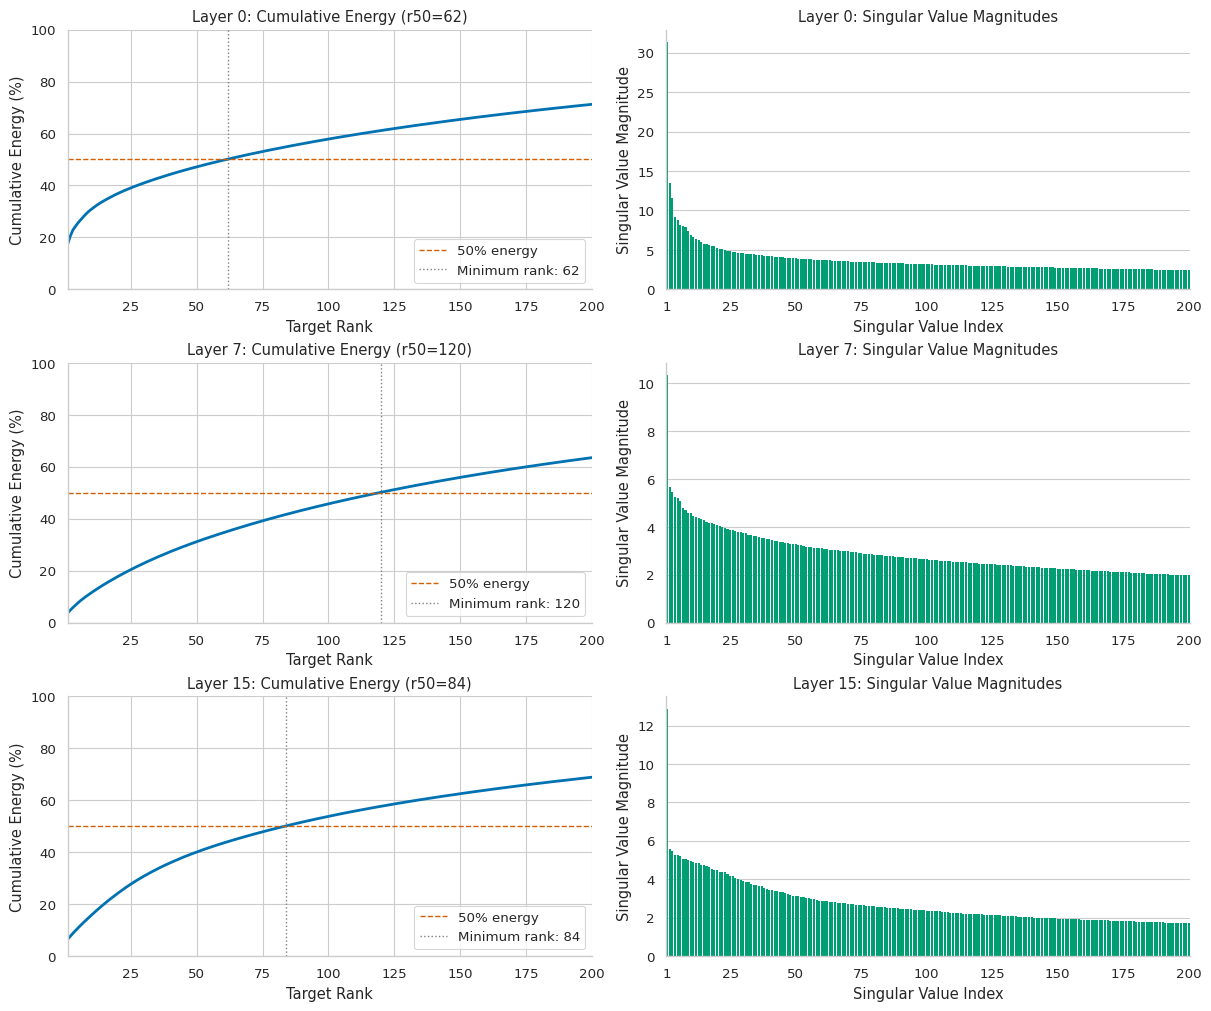

In [10]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid', context='paper', font_scale=1.1)

fig, axes = plt.subplots(
    3, 2, figsize=(12, 10), constrained_layout=True
)

for row, layer_id in enumerate(LAYERS):
    result = spectra[layer_id]
    n = min(200, len(result['singular_values']))

    plot_df = pd.DataFrame({
        'rank': np.arange(1, n + 1),
        'singular_value': result['singular_values'][:n],
        'cumulative_energy_pct': (
            result['cumulative_energy_pct'][:n]
        ),
    })

    # 累積能量折線圖
    ax = axes[row, 0]
    sns.lineplot(
        data=plot_df,
        x='rank',
        y='cumulative_energy_pct',
        estimator=None,
        color='#0072B2',
        linewidth=2,
        ax=ax,
    )

    ax.axhline(
        50, color='#D55E00', linestyle='--',
        linewidth=1, label='50% energy'
    )

    r50 = result['rank_50']
    if r50 <= n:
        ax.axvline(
            r50, color='gray', linestyle=':',
            linewidth=1, label=f'Minimum rank: {r50}'
        )

    ax.set(
        title=f'Layer {layer_id}: Cumulative Energy (r50={r50})',
        xlabel='Target Rank',
        ylabel='Cumulative Energy (%)',
        xlim=(1, n),
        ylim=(0, 100),
    )
    ax.legend(loc='lower right')

    # 奇異值大小長條圖
    # seaborn 將 rank 視為類別，橫軸座標從 0 開始
    ax = axes[row, 1]
    sns.barplot(
        data=plot_df,
        x='rank',
        y='singular_value',
        errorbar=None,
        color='#009E73',
        saturation=1,
        linewidth=0,
        ax=ax,
    )

    tick_ranks = [1] + list(range(25, n + 1, 25))
    if tick_ranks[-1] != n:
        tick_ranks.append(n)

    ax.set_xticks([rank - 1 for rank in tick_ranks])
    ax.set_xticklabels(tick_ranks, rotation=0)
    ax.set(
        title=f'Layer {layer_id}: Singular Value Magnitudes',
        xlabel='Singular Value Index',
        ylabel='Singular Value Magnitude',
        xlim=(-0.5, n - 0.5),
    )
    ax.set_ylim(bottom=0)
    ax.grid(axis='x', visible=False)

sns.despine(fig=fig)

fig.savefig(
    OUTPUT_DIR / 'q4_six_charts_seaborn.png',
    dpi=300,
    bbox_inches='tight',
)
plt.show()